# Matrix Spike Duplicate (MSD) Data Exploration

## Setup

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("MSD data exploration libraries loaded successfully.")

MSD data exploration libraries loaded successfully.


## 1. Load MSD Data

In [53]:
RAW_DIR = Path("../data/raw")

excel_files = list(
    RAW_DIR.glob("QC Anomaly Training Data*.xlsx")
)

print("Excel files found:")

for file in excel_files:
    print(file.name)

if len(excel_files) == 0:
    raise FileNotFoundError(
        "No QC Anomaly Training Data Excel file was found in ../data/raw/"
    )

FILE_PATH = excel_files[0]

print("\nUsing dataset:")
print(FILE_PATH)

Excel files found:
QC Anomaly Training Data v2 (1).xlsx

Using dataset:
../data/raw/QC Anomaly Training Data v2 (1).xlsx


In [54]:
msd = pd.read_excel(
    FILE_PATH,
    sheet_name="MSD assessment"
)

msd = msd.dropna(axis=1, how="all")

print(f"MSD rows loaded: {len(msd):,}")
print(f"Useful columns loaded: {msd.shape[1]}")

display(msd.head())

MSD rows loaded: 22,886
Useful columns loaded: 19


,ANALYTICAL_TYPE,QC_TYPE,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,NUMERIC_FINAL_VALUE,PARENT_NUMERIC_FINAL_VALUE,PRECISION_STATUS,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,AbsDiff,Avg,Abs%Diff,Fail Limit,Warn Limit,Status
0,Replicate,MS,GE_IMS40Q12,CU,MG_KG,2021-07-20 14:17:36.000,-1780.355970,30.808299,IgnoreFailure,10,5.0,15.0,5.0,1811.164269,-874.773835,207.043718,10.571576,6.705595,Failure
1,Replicate,MS,GE_ICP40Q12,CR,MG_KG,2021-09-02 15:51:13.000,-110.072261,-116.916780,Pass,15,2.5,15.0,2.5,6.844518,-113.494521,6.030704,17.202750,10.911776,Pass
2,Replicate,MS,GE_ICP40Q12,CR,MG_KG,2021-04-28 03:04:33.000,-81.145279,-82.605612,Pass,15,2.5,15.0,2.5,1.460333,-81.875446,1.783603,18.053418,11.451359,Pass
3,Replicate,MS,GE_ICP40Q12,BI,MG_KG,2021-03-22 06:43:40.000,-65.592040,-65.592040,Pass,10,12.5,15.0,12.5,0.000000,-65.592040,0.000000,29.057191,18.431098,Pass
4,Replicate,MS,GE_ICP40Q12,BI,MG_KG,2020-12-14 07:39:45.540,-70.158416,-58.553398,Pass,10,12.5,15.0,12.5,11.605018,-64.355907,18.032560,29.423236,18.663283,Pass


## 2. Dataset Structure

In [55]:
print("Dataset shape:")
print(msd.shape)

print("\nColumns:")

for column in msd.columns:
    print(f"- {column}")

Dataset shape:
(22886, 19)

Columns:
- ANALYTICAL_TYPE
- QC_TYPE
- SCHEME_CODE
- ANALYTE_CODE
- UNIT_CODE
- ANALYSED_DATE
- NUMERIC_FINAL_VALUE
- PARENT_NUMERIC_FINAL_VALUE
- PRECISION_STATUS
- LIM_REP_VALUE
- STAT_DL_VALUE
- LIM_REP_DUP_VALUE
- STAT_DL_DUP_VALUE
- AbsDiff
- Avg
- Abs%Diff
- Fail Limit
- Warn Limit
- Status


## 3. MSD Data Quality Assessment

In [56]:
missing_summary = pd.DataFrame({
    "Missing_Count": msd.isna().sum(),
    "Missing_Percent": (msd.isna().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    "Missing_Count",
    ascending=False
)

display(missing_summary)

,Missing_Count,Missing_Percent
ANALYTE_CODE,225,0.98
ANALYTICAL_TYPE,0,0.00
STAT_DL_VALUE,0,0.00
Warn Limit,0,0.00
Fail Limit,0,0.00
Abs%Diff,0,0.00
Avg,0,0.00
AbsDiff,0,0.00
STAT_DL_DUP_VALUE,0,0.00
LIM_REP_DUP_VALUE,0,0.00


In [57]:
print(f"Duplicate rows: {msd.duplicated().sum():,}")

print(
    f"Zero NUMERIC_FINAL_VALUE: "
    f"{(msd['NUMERIC_FINAL_VALUE'] == 0).sum():,}"
)

print(
    f"Negative NUMERIC_FINAL_VALUE: "
    f"{(msd['NUMERIC_FINAL_VALUE'] < 0).sum():,}"
)

print(
    f"Zero PARENT_NUMERIC_FINAL_VALUE: "
    f"{(msd['PARENT_NUMERIC_FINAL_VALUE'] == 0).sum():,}"
)

print(
    f"Negative PARENT_NUMERIC_FINAL_VALUE: "
    f"{(msd['PARENT_NUMERIC_FINAL_VALUE'] < 0).sum():,}"
)

Duplicate rows: 1,990
Zero NUMERIC_FINAL_VALUE: 15
Negative NUMERIC_FINAL_VALUE: 2,356
Zero PARENT_NUMERIC_FINAL_VALUE: 13
Negative PARENT_NUMERIC_FINAL_VALUE: 2,300


## 4. Existing MSD Precision Status Distribution

In [58]:
precision_status = (
    msd["PRECISION_STATUS"]
    .value_counts(dropna=False)
    .rename_axis("PRECISION_STATUS")
    .reset_index(name="Count")
)

precision_status["Percent"] = (
    precision_status["Count"] / len(msd) * 100
).round(2)

display(precision_status)

,PRECISION_STATUS,Count,Percent
0,Pass,19819,86.60
1,Warning,1471,6.43
2,IgnoreFailure,1241,5.42
3,Failure,330,1.44
4,NotTested,25,0.11


In [59]:
status_summary = (
    msd["Status"]
    .value_counts(dropna=False)
    .rename_axis("Status")
    .reset_index(name="Count")
)

status_summary["Percent"] = (
    status_summary["Count"] / len(msd) * 100
).round(2)

display(status_summary)

,Status,Count,Percent
0,Pass,19844,86.71
1,Failure,1572,6.87
2,Warning,1470,6.42


## 5. MSD Precision Behaviour Across Result Magnitude

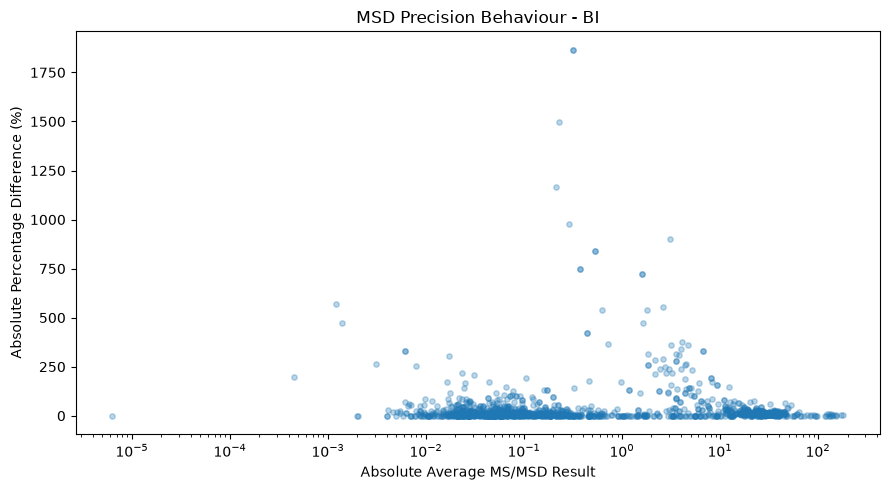

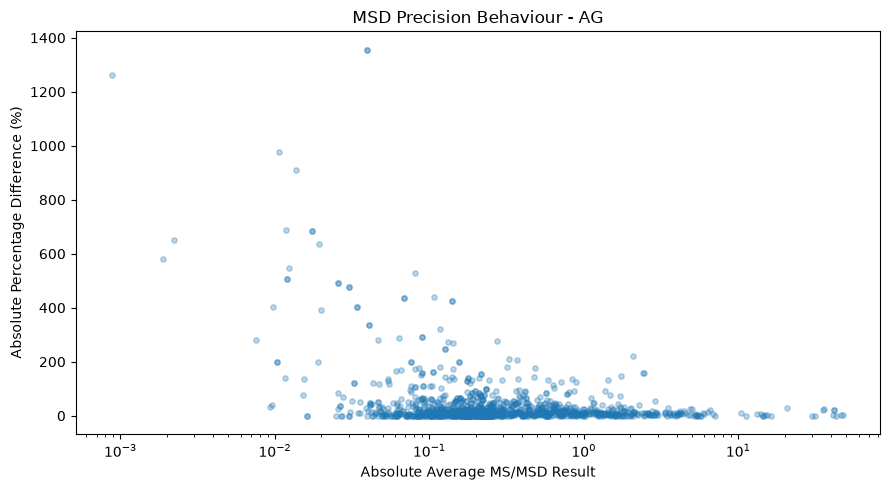

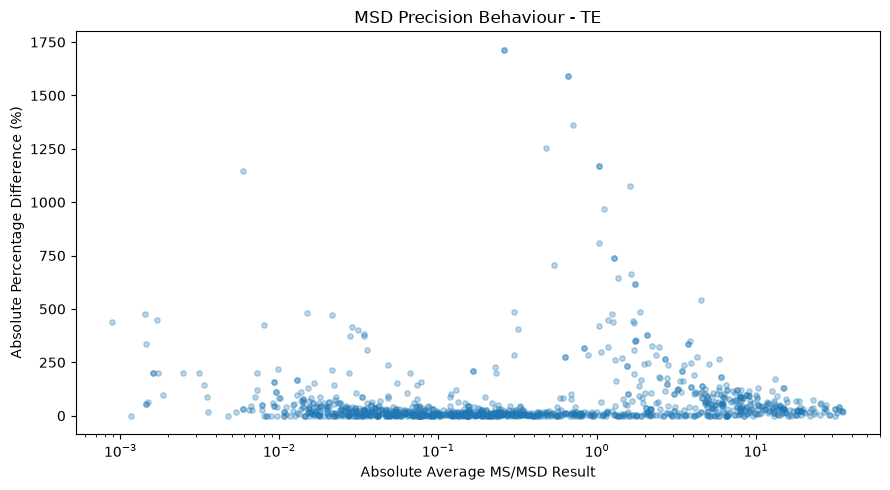

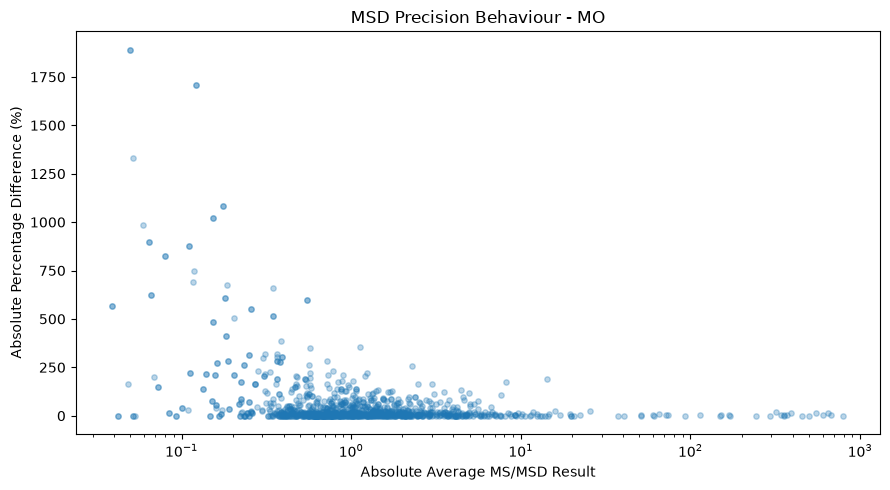

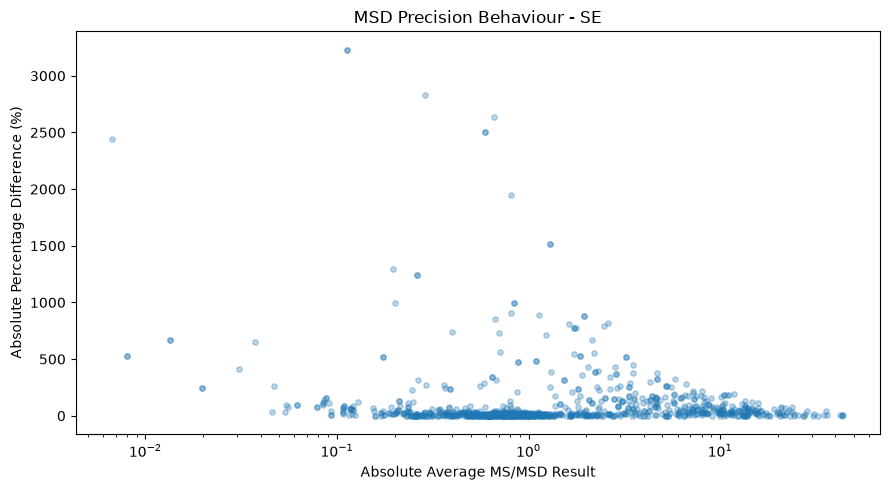

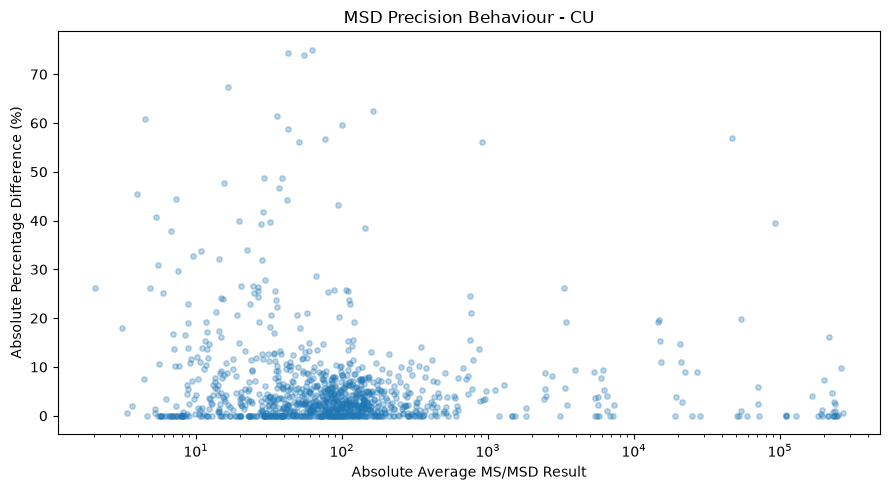

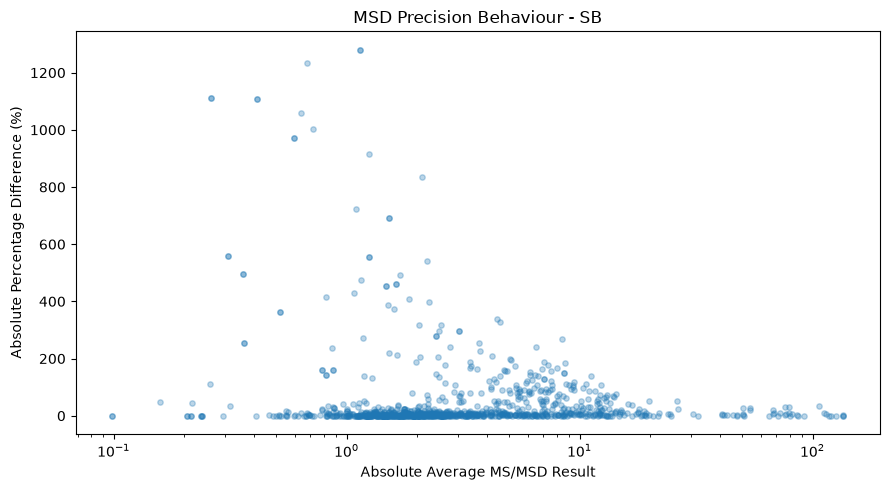

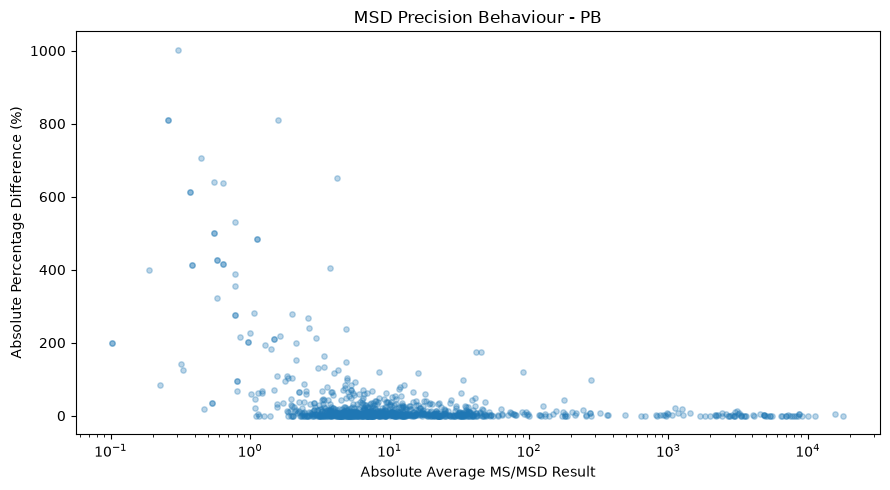

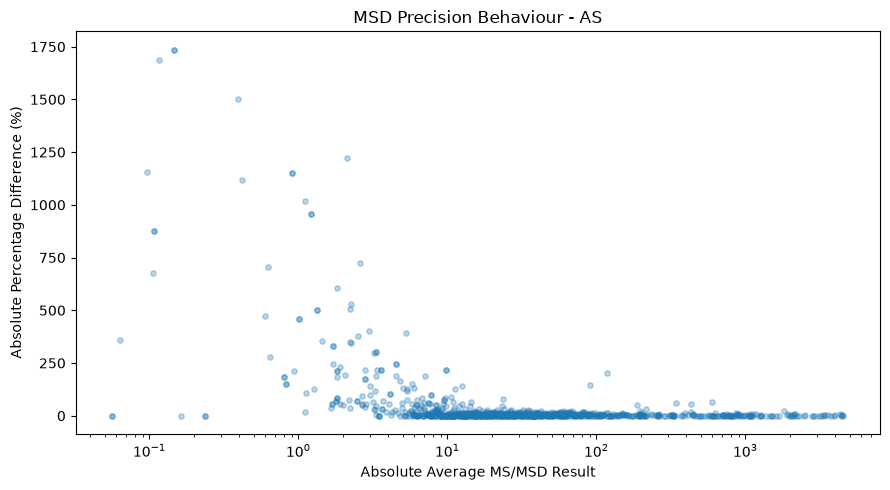

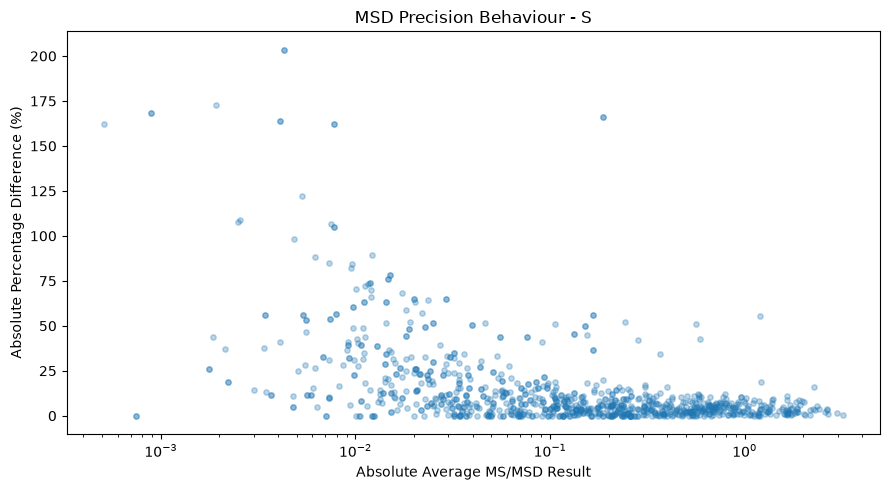

In [60]:
msd_plot = msd[
    [
        "ANALYTE_CODE",
        "Avg",
        "Abs%Diff",
        "PRECISION_STATUS"
    ]
].dropna().copy()

msd_plot["ABS_AVG"] = msd_plot["Avg"].abs()

msd_plot = msd_plot[
    msd_plot["ABS_AVG"] > 0
]

top_analytes = (
    msd_plot["ANALYTE_CODE"]
    .value_counts()
    .head(10)
    .index
)

for analyte in top_analytes:
    analyte_data = msd_plot[
        msd_plot["ANALYTE_CODE"] == analyte
    ].copy()

    x_limit = analyte_data["ABS_AVG"].quantile(0.99)
    y_limit = analyte_data["Abs%Diff"].quantile(0.99)

    plot_data = analyte_data[
        (analyte_data["ABS_AVG"] <= x_limit) &
        (analyte_data["Abs%Diff"] <= y_limit)
    ]

    plt.figure(figsize=(9, 5))

    plt.scatter(
        plot_data["ABS_AVG"],
        plot_data["Abs%Diff"],
        alpha=0.3,
        s=15
    )

    plt.xscale("log")

    plt.title(f"MSD Precision Behaviour - {analyte}")
    plt.xlabel("Absolute Average MS/MSD Result")
    plt.ylabel("Absolute Percentage Difference (%)")

    plt.tight_layout()
    plt.show()

- MSD precision changes with result magnitude.
- Lower or moderate result magnitudes often show larger percentage differences between MS and MSD.
- Higher-magnitude results are generally more tightly grouped near 0% difference.
- The amount of variability differs between analytes.
- Some analytes show much larger spread than others.
- This indicates that MSD precision is both result-magnitude dependent and analyte-specific.
- Large Abs%Diff values should therefore be interpreted in context rather than treated the same across all analytes and result ranges.
- These plots do not yet prove which points are true anomalies.
- The next step is to compare these patterns with the existing PRECISION_STATUS classifications to see which unusual points are already known Pass, Warning, Failure, or IgnoreFailure results.

## 6. Existing CCLAS MSD Precision Status Across Result Magnitude

This section compares MS/MSD precision behaviour with the existing CCLAS `PRECISION_STATUS` classifications. Results are examined by analyte and result magnitude to determine where existing Pass, Warning, Failure and IgnoreFailure classifications occur.

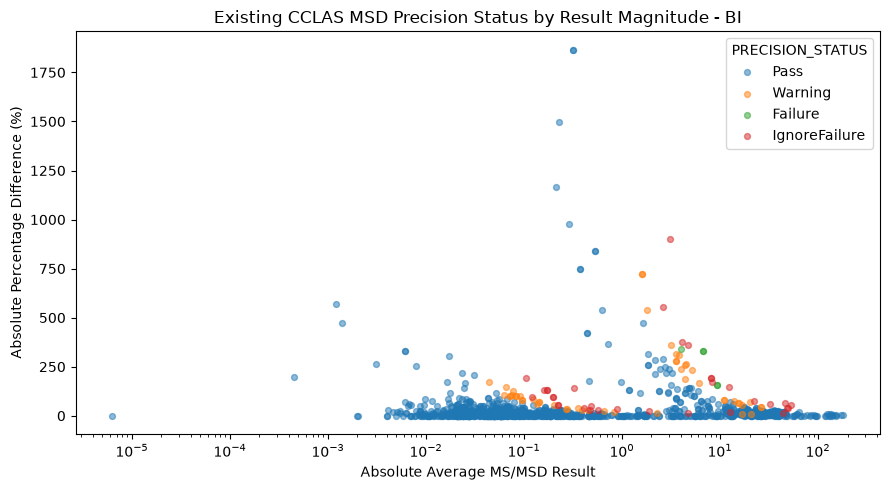

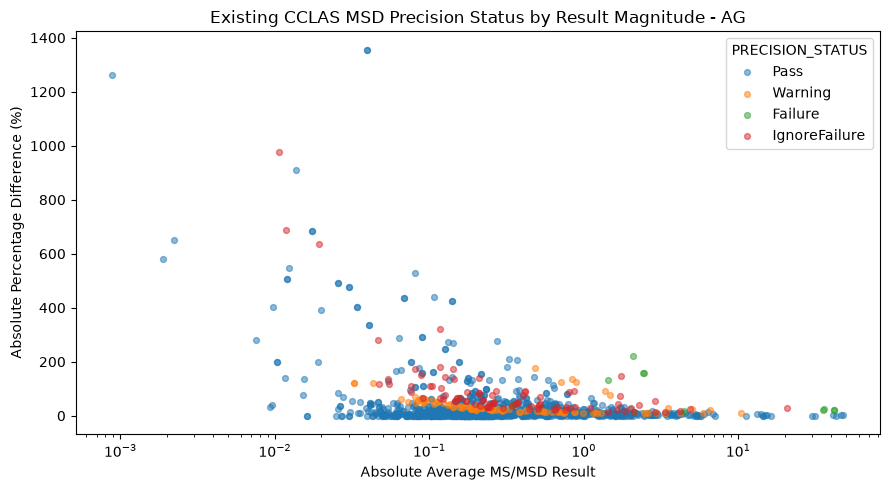

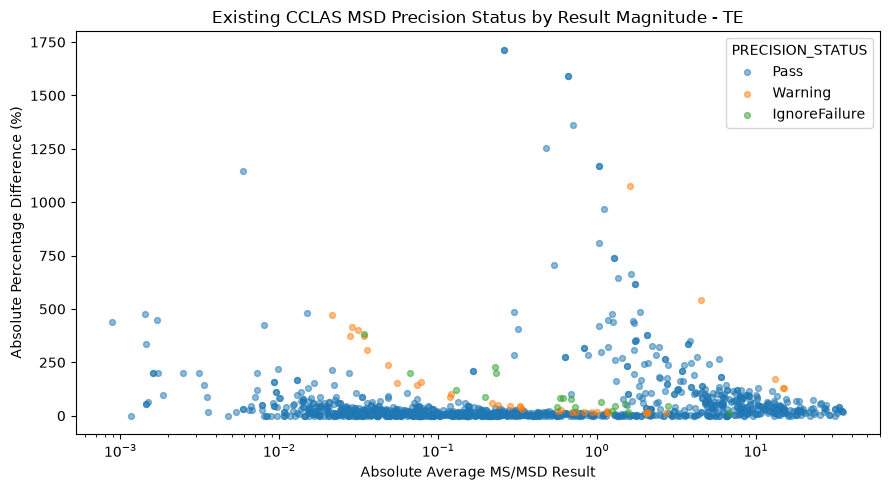

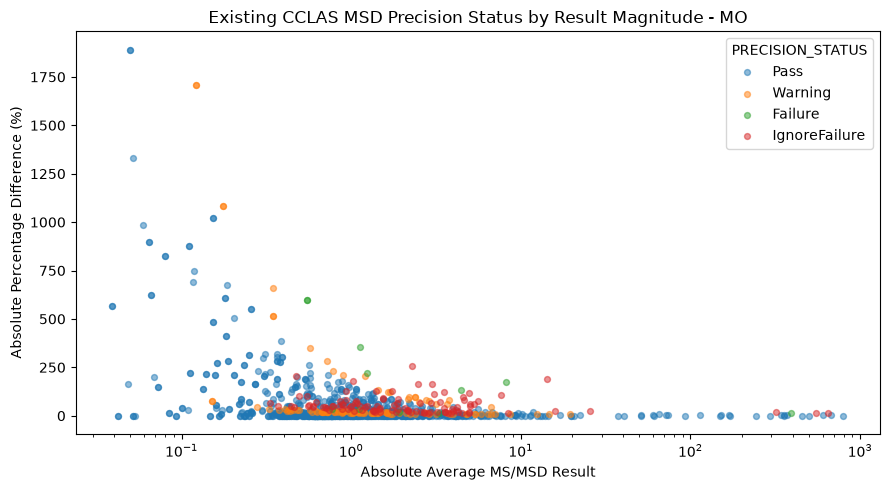

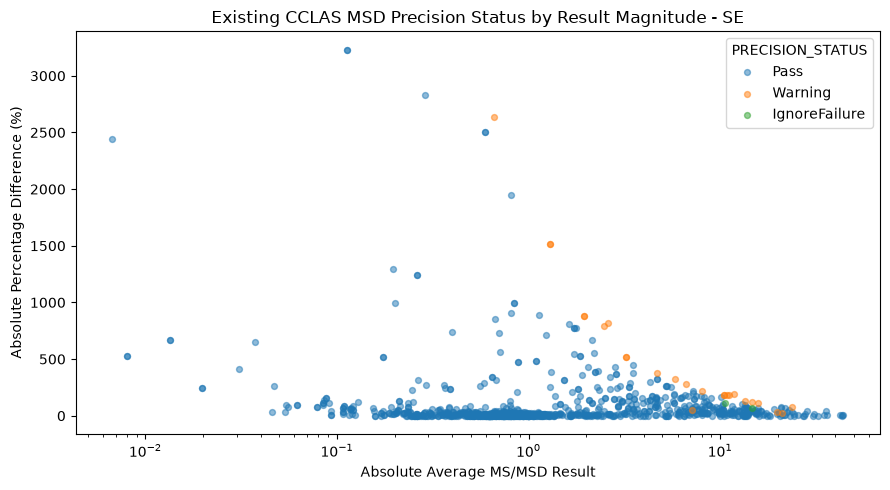

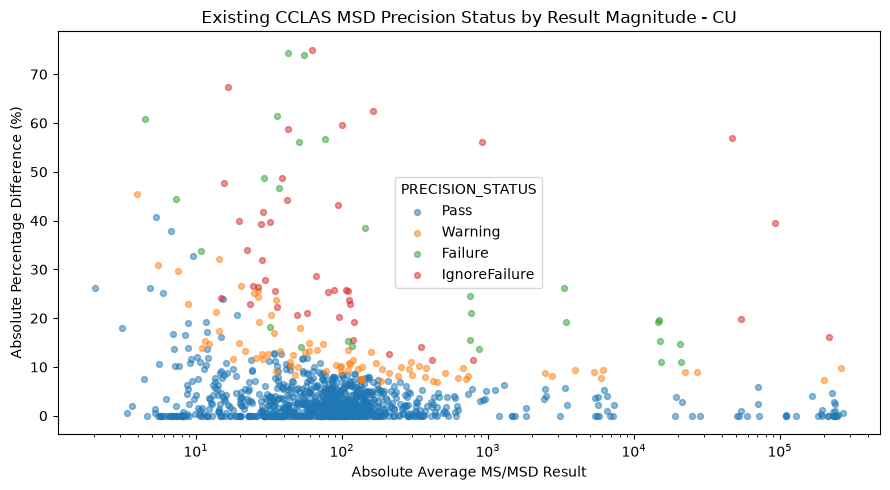

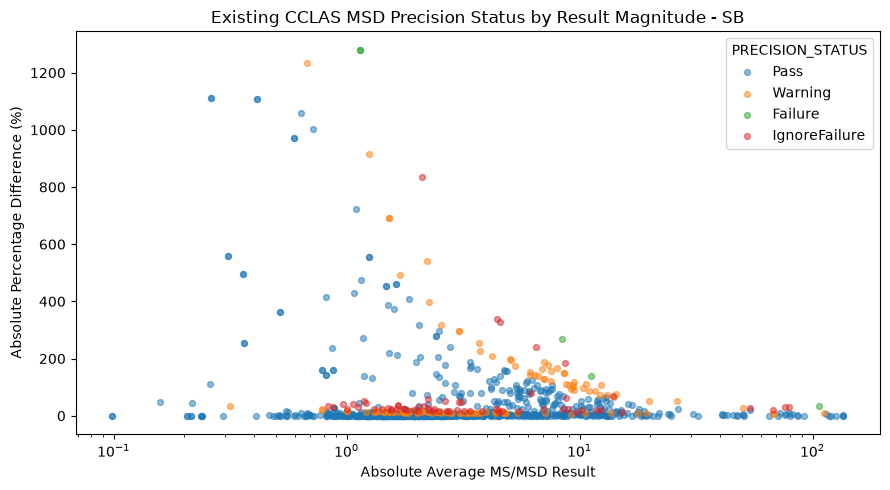

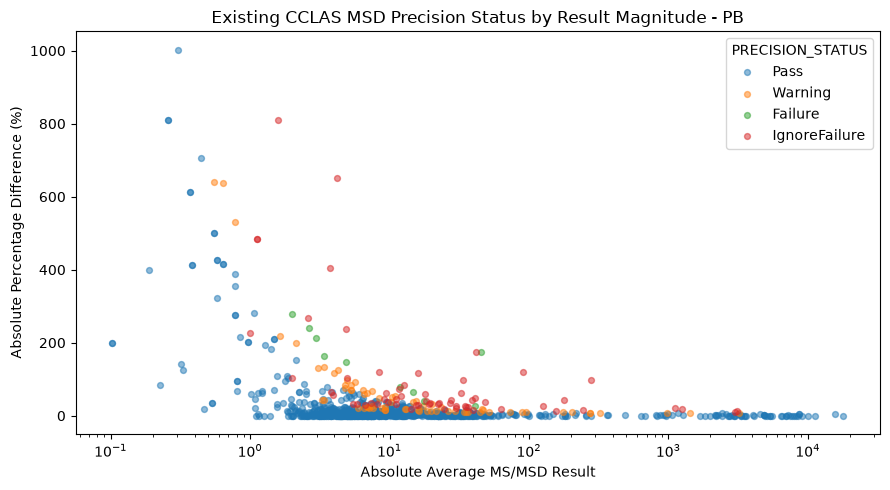

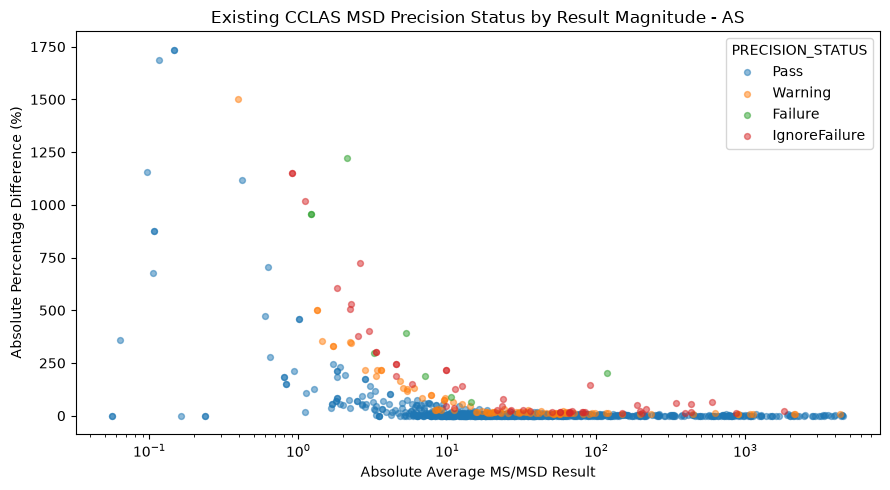

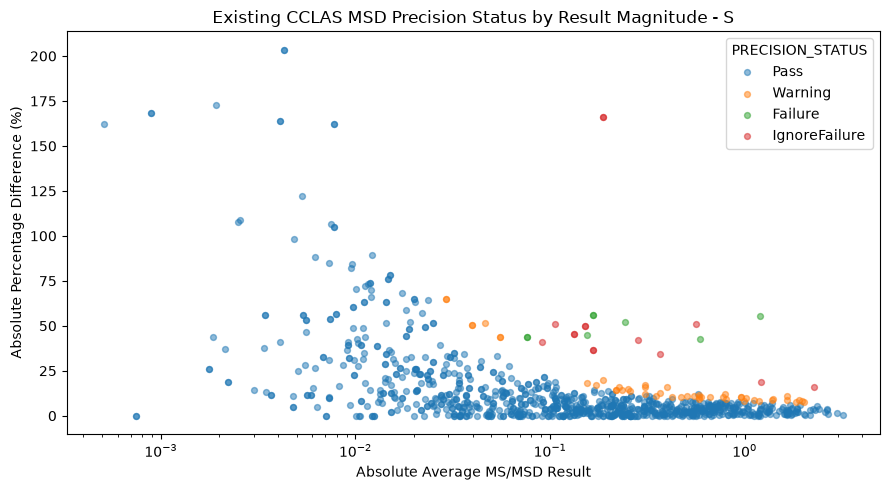

In [61]:
# Prepare MSD data for comparison with existing CCLAS precision status

status_plot = msd[
    [
        "ANALYTE_CODE",
        "Avg",
        "Abs%Diff",
        "PRECISION_STATUS"
    ]
].copy()

# Remove rows that cannot be used in this analyte-level precision plot
status_plot = status_plot.dropna(
    subset=[
        "ANALYTE_CODE",
        "Avg",
        "Abs%Diff",
        "PRECISION_STATUS"
    ]
)

# Use the absolute average MS/MSD result as result magnitude
status_plot["ABS_AVG"] = status_plot["Avg"].abs()

# Zero values cannot be displayed on a log-scaled x-axis
status_plot = status_plot[
    status_plot["ABS_AVG"] > 0
].copy()

# Focus visualisation on analytes with the most MSD observations
top_analytes = (
    status_plot["ANALYTE_CODE"]
    .value_counts()
    .head(10)
    .index
)

# Existing CCLAS precision classifications
status_order = [
    "Pass",
    "Warning",
    "Failure",
    "IgnoreFailure",
    "NotTested"
]

for analyte in top_analytes:

    analyte_data = status_plot[
        status_plot["ANALYTE_CODE"] == analyte
    ].copy()

    # Restrict the displayed range only for clearer visualisation.
    # These observations are NOT removed from the original MSD dataset.
    x_limit = analyte_data["ABS_AVG"].quantile(0.99)
    y_limit = analyte_data["Abs%Diff"].quantile(0.99)

    plot_data = analyte_data[
        (analyte_data["ABS_AVG"] <= x_limit) &
        (analyte_data["Abs%Diff"] <= y_limit)
    ]

    plt.figure(figsize=(9, 5))

    for status in status_order:

        status_data = plot_data[
            plot_data["PRECISION_STATUS"] == status
        ]

        if not status_data.empty:

            plt.scatter(
                status_data["ABS_AVG"],
                status_data["Abs%Diff"],
                alpha=0.5,
                s=18,
                label=status
            )

    plt.xscale("log")

    plt.title(
        f"Existing CCLAS MSD Precision Status by Result Magnitude - {analyte}"
    )

    plt.xlabel(
        "Absolute Average MS/MSD Result"
    )

    plt.ylabel(
        "Absolute Percentage Difference (%)"
    )

    plt.legend(
        title="PRECISION_STATUS"
    )

    plt.tight_layout()
    plt.show()

Conclude from these plots:

- Existing CCLAS precision classifications vary across analytes and result magnitudes.
- Warning, Failure and IgnoreFailure results do not occur at one universal absolute percentage difference.
- Some large relative differences remain classified as Pass, particularly within analyte- and result-magnitude-specific regions.
- This confirms that MSD precision should be interpreted using both analyte and result-magnitude context.
- The existing CCLAS classifications provide a baseline for identifying additional unusual historical or multivariate MSD behaviour in later anomaly-detection stages.

7. Historical MSD Precision Behaviour and Anomaly Candidates
The previous sections established the existing CCLAS precision classifications and showed how MS/MSD precision behaviour varies across analytes and result magnitudes. The next stage examines historical MSD precision behaviour to identify results that are unusual relative to comparable historical results, while retaining the existing CCLAS precision status as context.

In [62]:
# Prepare MSD records for historical precision analysis

historical_msd = msd[
    [
        "SCHEME_CODE",
        "ANALYTE_CODE",
        "UNIT_CODE",
        "ANALYSED_DATE",
        "Avg",
        "Abs%Diff",
        "PRECISION_STATUS"
    ]
].copy()

# Remove rows missing fields needed for comparison
historical_msd = historical_msd.dropna(
    subset=[
        "SCHEME_CODE",
        "ANALYTE_CODE",
        "UNIT_CODE",
        "ANALYSED_DATE",
        "Avg",
        "Abs%Diff"
    ]
)

# Result magnitude of the paired MS/MSD result
historical_msd["ABS_AVG"] = historical_msd["Avg"].abs()

# Remove zero magnitude because log10 cannot be calculated for zero
historical_msd = historical_msd[
    historical_msd["ABS_AVG"] > 0
].copy()

# Convert date field
historical_msd["ANALYSED_DATE"] = pd.to_datetime(
    historical_msd["ANALYSED_DATE"]
)

# Create result-magnitude bands.
# This keeps low-, medium- and high-magnitude MSD behaviour separate.
historical_msd["MAGNITUDE_BAND"] = np.floor(
    np.log10(historical_msd["ABS_AVG"])
)

print("Historical MSD rows available:", len(historical_msd))

display(
    historical_msd[
        [
            "SCHEME_CODE",
            "ANALYTE_CODE",
            "UNIT_CODE",
            "ANALYSED_DATE",
            "ABS_AVG",
            "MAGNITUDE_BAND",
            "Abs%Diff",
            "PRECISION_STATUS"
        ]
    ].head()
)

Historical MSD rows available: 22661


,SCHEME_CODE,ANALYTE_CODE,UNIT_CODE,ANALYSED_DATE,ABS_AVG,MAGNITUDE_BAND,Abs%Diff,PRECISION_STATUS
0,GE_IMS40Q12,CU,MG_KG,2021-07-20 14:17:36.000,874.773835,2.0,207.043718,IgnoreFailure
1,GE_ICP40Q12,CR,MG_KG,2021-09-02 15:51:13.000,113.494521,2.0,6.030704,Pass
2,GE_ICP40Q12,CR,MG_KG,2021-04-28 03:04:33.000,81.875446,1.0,1.783603,Pass
3,GE_ICP40Q12,BI,MG_KG,2021-03-22 06:43:40.000,65.592040,1.0,0.000000,Pass
4,GE_ICP40Q12,BI,MG_KG,2020-12-14 07:39:45.540,64.355907,1.0,18.032560,Pass


7. MSD Precision Behaviour Over Time

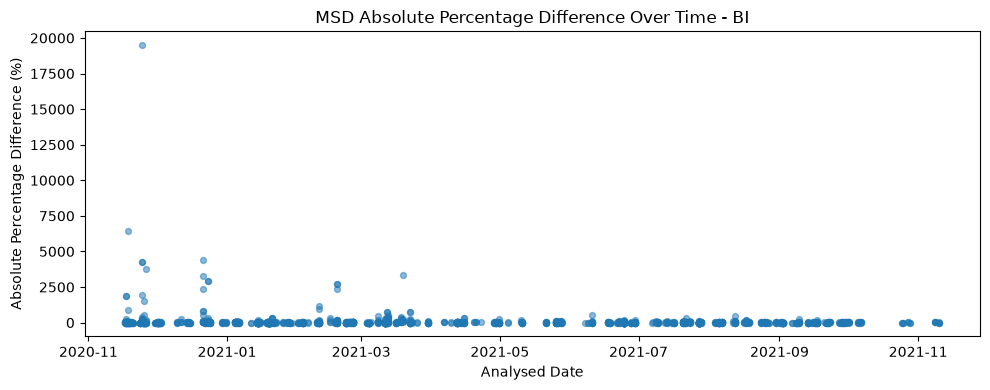

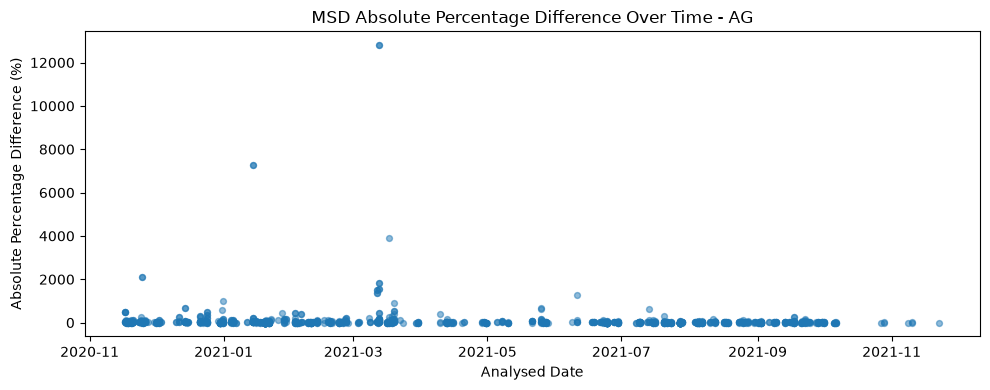

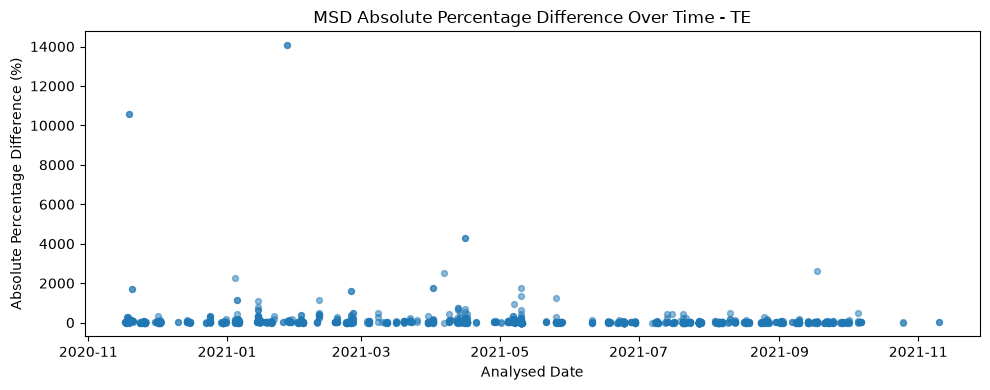

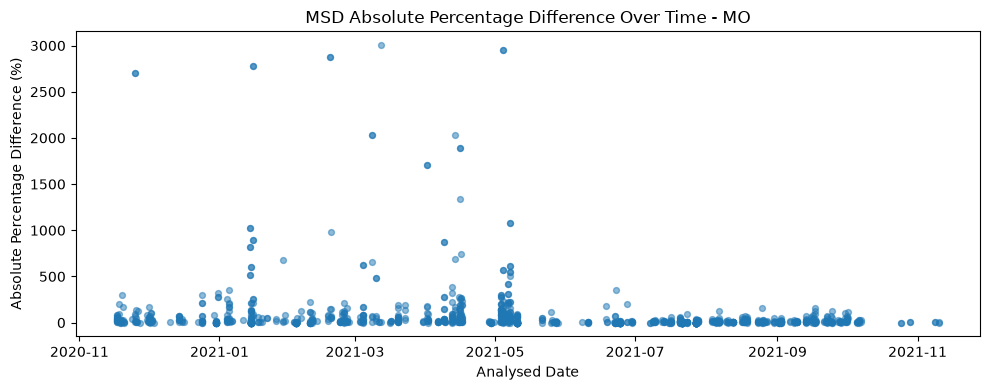

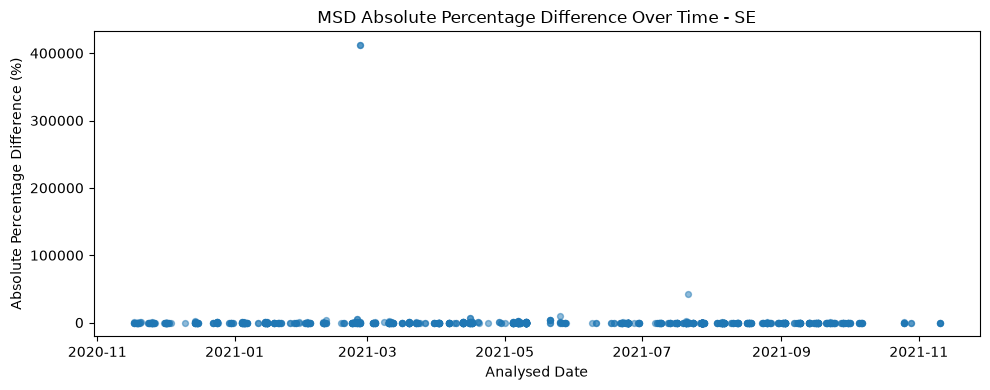

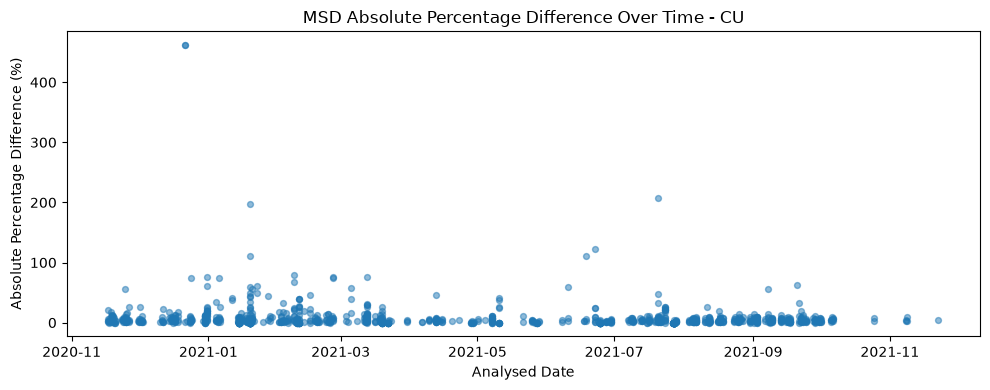

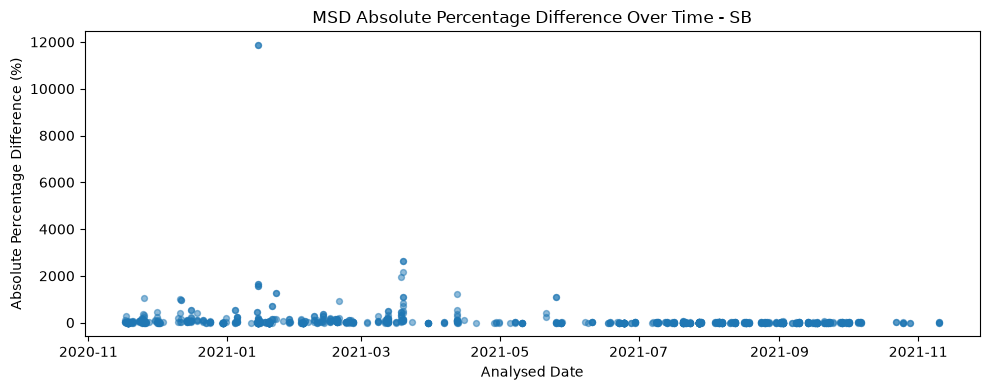

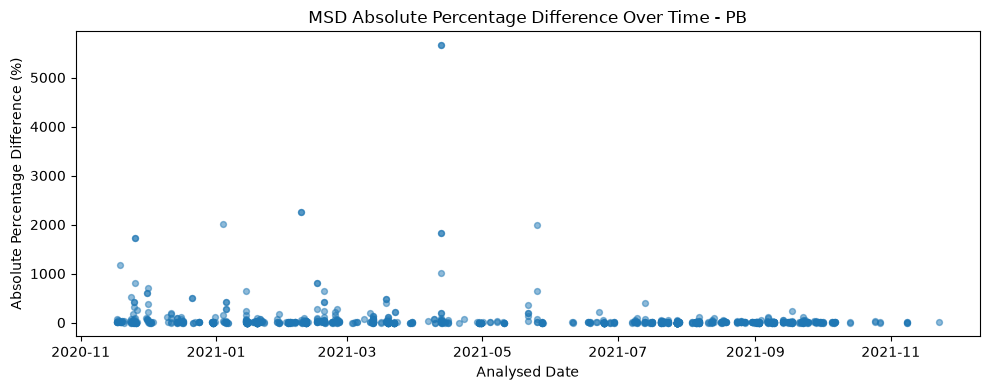

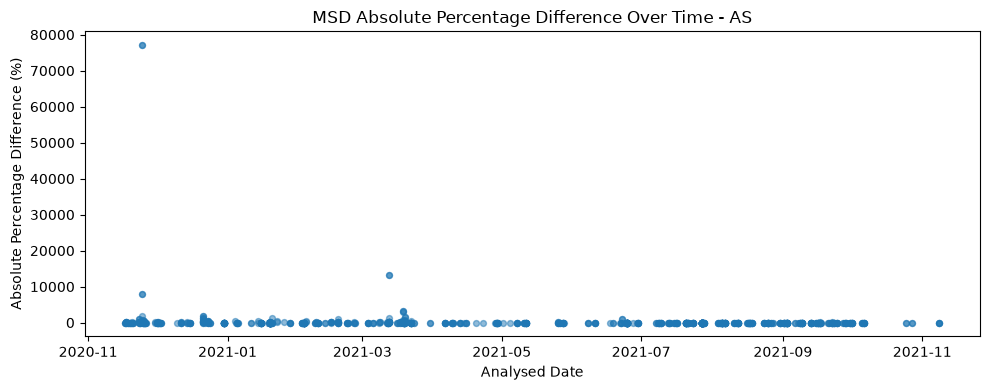

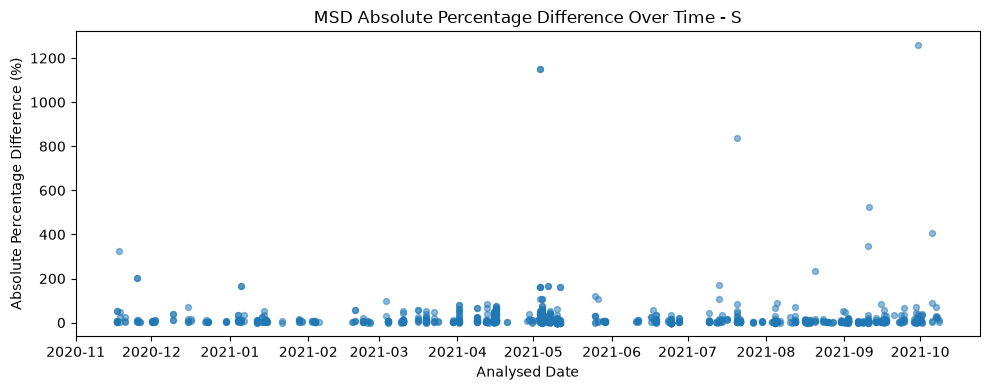

In [63]:
# Prepare MSD data for time-based exploration

time_plot = msd[
    [
        "ANALYTE_CODE",
        "ANALYSED_DATE",
        "Abs%Diff",
        "PRECISION_STATUS"
    ]
].copy()

time_plot["ANALYSED_DATE"] = pd.to_datetime(
    time_plot["ANALYSED_DATE"]
)

time_plot = time_plot.dropna(
    subset=[
        "ANALYTE_CODE",
        "ANALYSED_DATE",
        "Abs%Diff"
    ]
)

top_analytes = (
    time_plot["ANALYTE_CODE"]
    .value_counts()
    .head(10)
    .index
)

for analyte in top_analytes:

    analyte_data = time_plot[
        time_plot["ANALYTE_CODE"] == analyte
    ].sort_values("ANALYSED_DATE")

    plt.figure(figsize=(10, 4))

    plt.scatter(
        analyte_data["ANALYSED_DATE"],
        analyte_data["Abs%Diff"],
        alpha=0.5,
        s=18
    )

    plt.title(
        f"MSD Absolute Percentage Difference Over Time - {analyte}"
    )

    plt.xlabel("Analysed Date")
    plt.ylabel("Absolute Percentage Difference (%)")

    plt.tight_layout()
    plt.show()

## 8. MSD Precision Limits and Existing Status